# **Table of Contents**

1. [Introduction](#1-introduction)

2. [Data Loading and Initial Exploration](#2-data-loading-and-initial-exploration)
   - [2.1 Initial Data Understanding](#21-initial-data-understanding)
   - [2.2 Importing Libraries](#22-importing-libraries)
   - [2.3 Initial Data Inspection](#23-initial-data-inspection)
   - [2.4 Data Manipulation](#24-data-manipulation)

3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
   - [3.1 Overview](#31-overview)
   - [3.2 Target (Churn)](#32-target-churn)
   - [3.3 Demographic Features](#33-demographic-features)
   - [3.4 Services](#34-services)
   - [3.5 Account Features](#35-account-features)
   - [3.6 Billing Features](#36-billing-features)

4. [Feature Relationships](#4-feature-relationships)
   - [4.1 Partner and Dependents](#41-partner-and-dependents)
   - [4.2 Contract and Tenure](#42-contract-and-tenure)
   - [4.3 Monthly and Total Charges by Tenure](#43-monthly-and-total-charges-by-tenure)
   - [4.4 Monthly Charges and InternetService](#44-monthly-charges-and-internetservice)
   - [4.5 Contract and Payment Method](#45-contract-and-payment-method)
   - [4.6 Tenure and Churn](#46-tenure-and-churn)
   - [4.7 Contract and Churn](#47-contract-and-churn)
   - [4.8 Internet Service and Churn](#48-internet-service-and-churn)
   - [4.9 Monthly Charges and Churn](#49-monthly-charges-and-churn)
   - [4.10 Total Charges and Churn](#410-total-charges-and-churn)
   - [4.11 Senior Citizens and Churn](#411-senior-citizens-and-churn)
   - [4.12 Correlation Matrix](#412-correlation-matrix)
   - [4.13 EDA Conclusions](#413-eda-conclusions)

5. [Data Preprocessing and Model Training](#5-data-preprocessing-and-model-training)
   - [5.1 Data Preprocessing](#51-data-preprocessing)
   - [5.2 Model Training](#52-model-training)
      - [5.2.1 K-Nearest Neighbors](#521-k-nearest-neighbors)
      - [5.2.2 Logistic Regression](#522-logistic-regression)
      - [5.2.3 Support Vector Machine](#523-support-vector-machine)

## **1 Introduction**

In the telecommunications industry, one of the key business problems is customer churn. Churn refers to a customer discontinuing the use of a company’s services within a certain period. A high churn rate directly affects revenue, customer acquisition costs, and overall customer lifetime value.

Reducing churn is particularly important for several reasons:

* acquiring a new customer typically requires significantly higher costs than retaining an existing one;
* premature customer departure reduces customer lifetime value and may prevent the company from recovering its acquisition costs;
* attempts to retain a customer immediately before departure often require discounts or special offers, which reduces profitability.
  
To manage churn more effectively, companies use data analysis and machine learning methods. Predictive models make it possible to estimate the probability of churn for individual customers and identify high-risk groups in advance so that targeted retention measures can be applied.

In this notebook, an exploratory data analysis of a telecommunications company’s customer data will be conducted to identify factors associated with churn. Several classification models, including logistic regression, KNN, and SVM, will then be built and compared to predict the probability of customer churn.

**Important**: the available observational data can reveal statistical associations with churn, but by themselves they do not allow causal relationships to be established.

## **2 Data Loading and Initial Exploration**

### **2.1 Initial Data Understanding**

**Feature descriptions:**

* `customerID` - unique customer identifier.
* `gender` - customer gender.
* `SeniorCitizen` - whether the customer is a senior citizen.
* `Partner` - whether the customer has a partner.
* `Dependents` - whether the customer has dependents.
* `tenure` - number of months the customer has been using the company's services.
* `PhoneService` - whether phone service is enabled.
* `MultipleLines` - whether multiple phone lines are enabled.
* `InternetService` - type of the customer's internet service.
* `OnlineSecurity` - whether the online security service is enabled.
* `OnlineBackup` - whether the online backup service is enabled.
* `DeviceProtection` - whether the device protection service is enabled.
* `TechSupport` - whether technical support is enabled.
* `StreamingTV` - whether the streaming TV service is enabled.
* `StreamingMovies` - whether the streaming movies service is enabled.
* `Contract` - type of customer contract.
* `PaperlessBilling` - whether the customer uses paperless billing.
* `PaymentMethod` - payment method.
* `MonthlyCharges` - customer's monthly charges.
* `TotalCharges` - customer's total charges over the entire service period.
* `Churn` - target feature: whether the customer stopped using the company's services.

### **2.2 Importing Libraries**

In [1]:
# Import essential libraries for data analysis and visualization

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import os
from pathlib import Path

# Suppress warning messages to keep the notebook output clean

warnings.filterwarnings("ignore")

# Set the default visualization style

sns.set_theme(style="darkgrid")

# Inspect available dataset files and their paths relative to the repository

for dirname, _, filenames in os.walk("data"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

data/raw.csv


### **2.3 Initial Data Inspection**

In [2]:
# Load the dataset into a DataFrame using a repository-relative path

data_path = Path("data/raw.csv")
df = pd.read_csv(data_path)

In [3]:
from pathlib import Path

data_path = Path("data/raw.csv")
df = pd.read_csv(data_path)

In [4]:
# Display the first five rows of the dataset

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Check the number of rows and columns in the dataset

df.shape

(7043, 21)

In [6]:
# Display the column names in the dataset

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
# Display a concise summary of the dataset structure and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


The `TotalCharges` feature immediately stands out: it is represented as a string, although conceptually it reflects the customer's total payments. In addition, the target variable `Churn` also has a string type. For further analysis and model building, both features need to be converted to a numerical format.

### **2.4 Data Manipulation**

In [8]:
# Encode the target variable as binary values

df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

In [9]:
# Convert TotalCharges to a numeric data type

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [10]:
# Check the data types after conversion

df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

We next check the dataset for missing values. After converting `TotalCharges` to a numerical format, invalid or empty strings were replaced with NaN.

In [11]:
# Check for missing values in each column

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

The data contains 11 missing values in the `TotalCharges` feature. They are likely associated with customers who have not yet completed their first month of service and therefore have not accumulated a total amount of charges. Next, we use `describe()` to inspect the distributions of the numerical features.

In [12]:
# Define numerical columns for descriptive analysis

numerical_columns = ["tenure", "MonthlyCharges", "TotalCharges"]

# Display the selected numerical columns

print(f"Numerical Columns: {', '.join(numerical_columns)}")

Numerical Columns: tenure, MonthlyCharges, TotalCharges


In [13]:
# Display descriptive statistics for numerical features

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


Based on `describe()`, the following observations can be made:

* `tenure` has a minimum value of 0. This is consistent with the assumption that some customers have only recently started using the company's services. These observations should be checked separately among the rows with missing `TotalCharges`.
* For `TotalCharges`, the mean value (2283.3) is noticeably higher than the median (1397.5). This indicates a right-skewed distribution: a small proportion of customers have significantly higher total charges. The large standard deviation (2266.8) also indicates substantial variability in the values.

In [14]:
# Display customers with zero tenure to inspect missing TotalCharges values

df[df["tenure"] == 0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,0
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,0
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,0
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,0
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,0
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,0
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,0
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,0
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,0
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,0


The check confirms that all 11 missing `TotalCharges` values correspond to customers with `tenure` = 0. Since there are only 11 such rows, removing them will not have a significant impact on the sample size and will help avoid issues during further analysis and model training.

We also remove `customerID`, since it is a unique identifier and provides no useful information for model building.

In [15]:
# Remove rows with zero tenure and missing TotalCharges

df = df.drop(df[df["tenure"] == 0].index)

Check duplicates before dropping ID (prevent deleting unique users).

In [16]:
# Check the number of duplicated rows

df.duplicated().sum()

np.int64(0)

In [17]:
# Remove the unique customer identifier

df = df.drop("customerID", axis=1)

## **3 Exploratory Data Analysis**

### **3.1 Overview**

As part of the exploratory data analysis, we will divide the features into several meaningful groups. This will help structure the subsequent analysis and systematically assess the relationship between each group of features and customer churn:

* **Demographic**: `gender`, `SeniorCitizen`, `Partner`, `Dependents`.
* **Service**: `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`.
* **Account**: `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`.
* **Billing**: `MonthlyCharges`, `TotalCharges`.

In [18]:
# Define demographic features

demographic_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

# Define service-related features

service_features = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# Define account-related features

account_features = [
    "tenure",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

# Define billing-related features

billing_features = [
    "MonthlyCharges",
    "TotalCharges"
]

### **3.2 Target (Churn)**

We begin the EDA by examining the distribution of the target variable `Churn`.

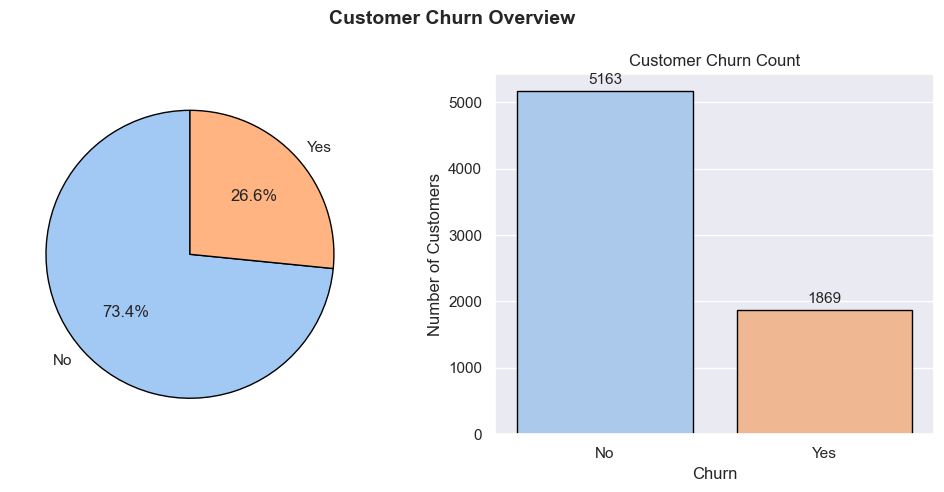

In [19]:
# Count the number of customers in each churn category

churn_stats = df["Churn"].value_counts()

# Create side-by-side plots for churn distribution

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

colors = sns.color_palette("pastel", df["Churn"].nunique())

# Display churn distribution as a pie chart

ax[0].pie(
    churn_stats,
    labels=["No", "Yes"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

# Display churn distribution as a count plot

sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    palette="pastel",
    edgecolor="black",
    legend=False,
    ax=ax[1] 
)

# Add value labels above the bars

for container in ax[1].containers:
    ax[1].bar_label(container, fontsize=11, padding=3)

# Customize the count plot

ax[1].set_title("Customer Churn Count")
ax[1].set_xlabel("Churn")
ax[1].set_ylabel("Number of Customers")
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(["No", "Yes"])

fig.suptitle("Customer Churn Overview", fontsize=14, fontweight="bold")

# Adjust spacing between subplots

plt.tight_layout();

The dataset shows a noticeable class imbalance: 73.4% of customers continued using the company's services, while 26.6% churned. This is important to take into account when training and evaluating models, since the accuracy metric in this situation may provide an overly optimistic view of classification performance.

### **3.3 Demographic Features**

We begin by looking at the demographic profile of the customers.

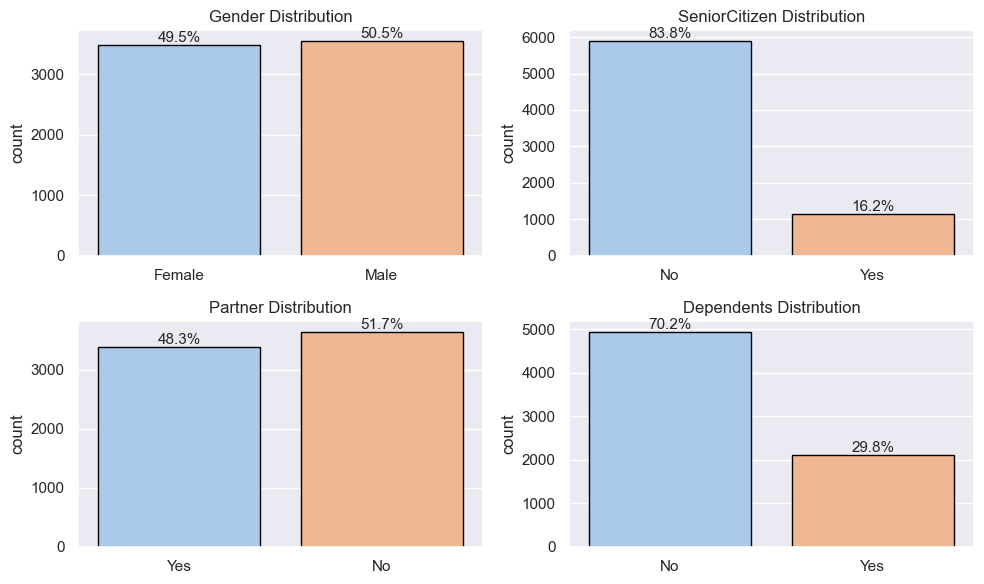

In [20]:
# Create a 2x2 grid for demographic feature distributions

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(10, 6)
)

# Flatten the axes array for easier iteration

axes = axes.flatten()

# Plot the distribution of each demographic feature

for ax, feature in zip(axes, demographic_features):
    sns.countplot(
        data=df,
        x=feature,
        hue=feature,
        palette="pastel",
        edgecolor="black",
        legend=False, 
        ax=ax
    )

    # Add percentage labels above the bars
    
    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[
                f"{x / len(df) * 100:.1f}%" 
                for x in container.datavalues],
            fontsize=11
        )

    # Customize plot titles and axis labels
    
    ax.set_title(f"{feature.capitalize()} Distribution")
    ax.set_xlabel('')


    # Replace binary values with readable labels for SeniorCitizen

    if feature == "SeniorCitizen":
        ax.set_title(f"{feature} Distribution")
        
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["No", "Yes"])
        
# Adjust spacing between subplots

plt.tight_layout();

* the distribution of gender and partner status is fairly balanced;
* the `SeniorCitizen` and `Dependents` features are unevenly distributed;
* senior citizens account for only 16.2% of the sample;
* most customers do not have dependents: such observations account for 70.2%, while customers with dependents make up 29.8%.

It is worth separately examining the relationship between the `Partner` and `Dependents` features, since they may partially describe similar customer characteristics.

### **3.4 Services**

Next, we look at customers’ service subscriptions to identify the most common services and the less represented categories.

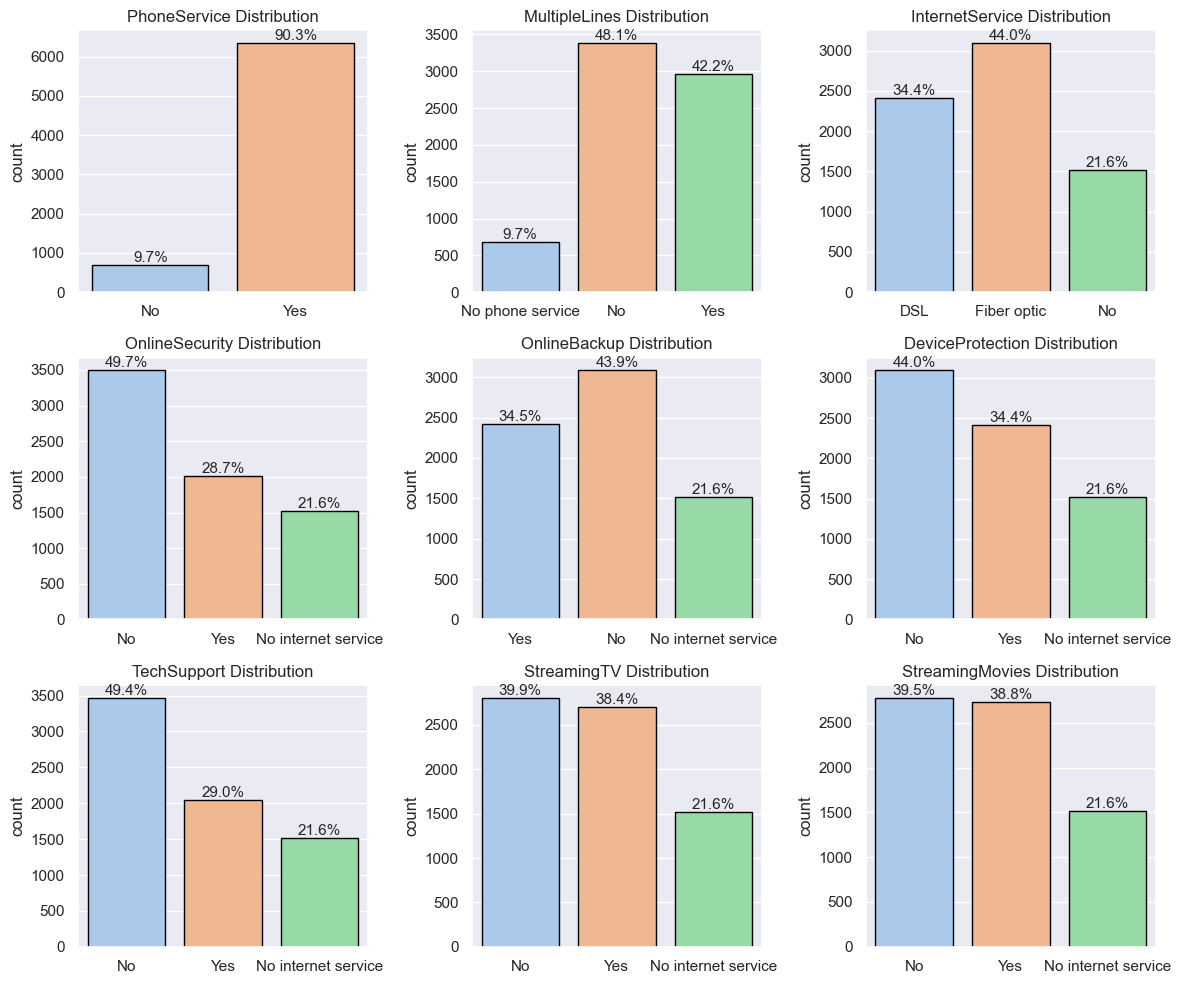

In [21]:
# Create a 3x3 grid for service feature distributions

fig, axes = plt.subplots(
    nrows=3, 
    ncols=3,
    figsize=(12, 10)
)

# Flatten the axes array for easier iteration

axes = axes.flatten()

# Plot the distribution of each service-related feature

for ax, feature in zip(axes, service_features):
    sns.countplot(
        data=df,
        x=feature,
        hue=feature,
        palette="pastel",
        edgecolor="black",
        legend=False,
        ax=ax
    )

    # Add percentage labels above the bars

    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[
                f"{x / len(df) * 100:.1f}%" 
                for x in container.datavalues
            ],
            fontsize=11
        )

    # Customize plot titles and axis labels

    ax.set_title(f"{feature} Distribution")
    ax.set_xlabel('')

# Adjust spacing between subplots

plt.tight_layout();

* `PhoneService` and `MultipleLines` partially duplicate information: the `No phone service` category in `MultipleLines` directly indicates the absence of phone service. Therefore, at the Feature Selection stage, it is worth checking whether both features need to be retained.
* Most customers use internet services: the most common connection type is `Fiber optic` (44.0%), followed by `DSL` (34.4%), while 21.6% of customers do not have internet service. Among additional internet services, a substantial proportion of customers do not use `OnlineSecurity`, `TechSupport`, `DeviceProtection`, or `OnlineBackup`, whereas subscriptions to `StreamingTV` and `StreamingMovies` are distributed much more evenly.

### **3.5 Account Features**

The distribution of customer tenure provides a clearer picture of how long customers typically stay with the company.

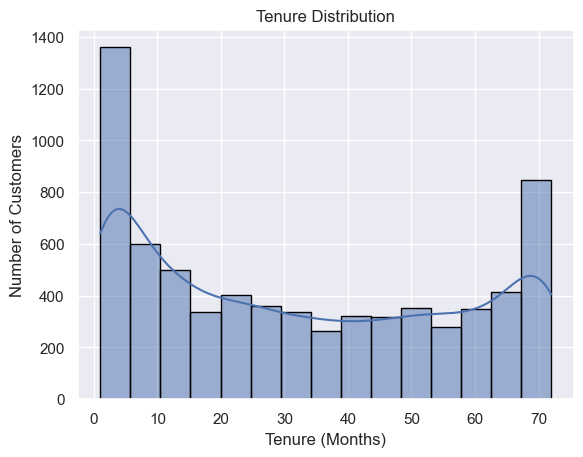

In [22]:
# Plot the distribution of customer tenure

sns.histplot(
    data=df,
    x="tenure",
    kde=True,
    edgecolor="black"
);

# Customize the plot title and axis labels

plt.title("Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers");

The `tenure` distribution shows pronounced concentrations among customers with short and, conversely, long service periods. This may be related to the contract type: customers with long-term contracts may potentially stay with the company longer, while those with month-to-month contracts may have shorter service periods. This hypothesis should be examined separately when analyzing the relationship between `tenure` and `Contract`.

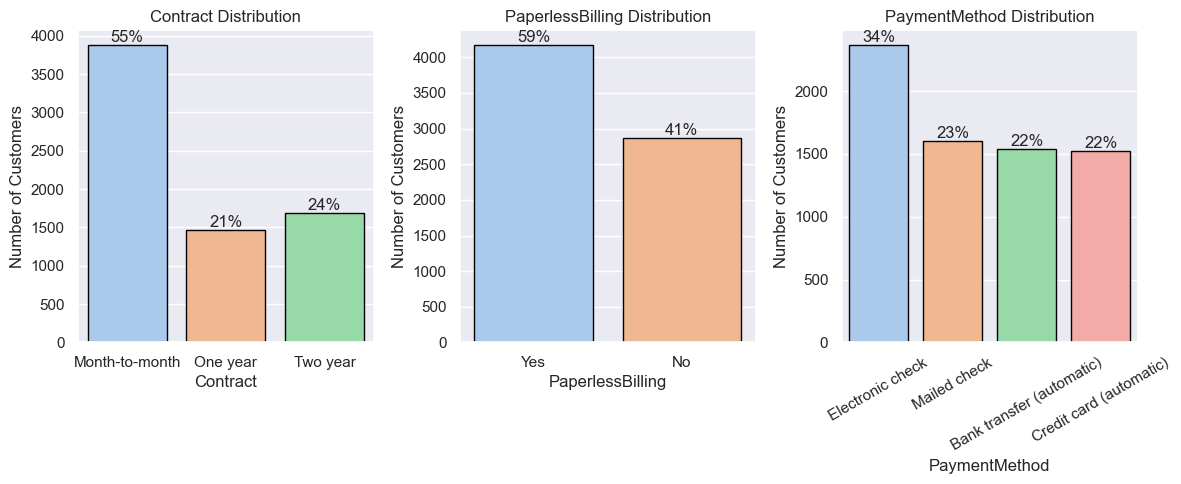

In [23]:
# Create side-by-side plots for account-related categorical features

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))

# Plot the distribution of each account-related feature

for ax, feature in zip(axes, account_features[1:]):
    ax = sns.countplot(
        data=df,
        x=feature,
        hue=feature,
        palette="pastel",
        edgecolor="black",
        legend=False,
        ax=ax
    )

    # Add percentage labels above the bars
    
    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[
                f"{x / len(df) * 100:.0f}%"
                for x in container.datavalues
            ]
        )

    # Rotate PaymentMethod labels for better readability

    if feature == "PaymentMethod":
        ax.tick_params(axis="x", rotation=30)

    # Customize plot titles and axis labels
    
    ax.set_title(f"{feature} Distribution")
    ax.set_ylabel("Number of Customers")

# Adjust spacing between subplots

plt.tight_layout();

Most customers use a `Month-to-month` contract, while the most common payment method is `Electronic check`.

In practice, month-to-month contracts may be associated with the use of `Electronic check`, since this payment method is well suited to regular monthly payments. However, the current plots show only the separate distributions of the features and do not allow us to confirm a relationship between them. The relationship between `Contract` and `PaymentMethod` should be examined separately later.

### **3.6 Billing Features**

We now turn to the two billing variables: `MonthlyCharges` and `TotalCharges`.


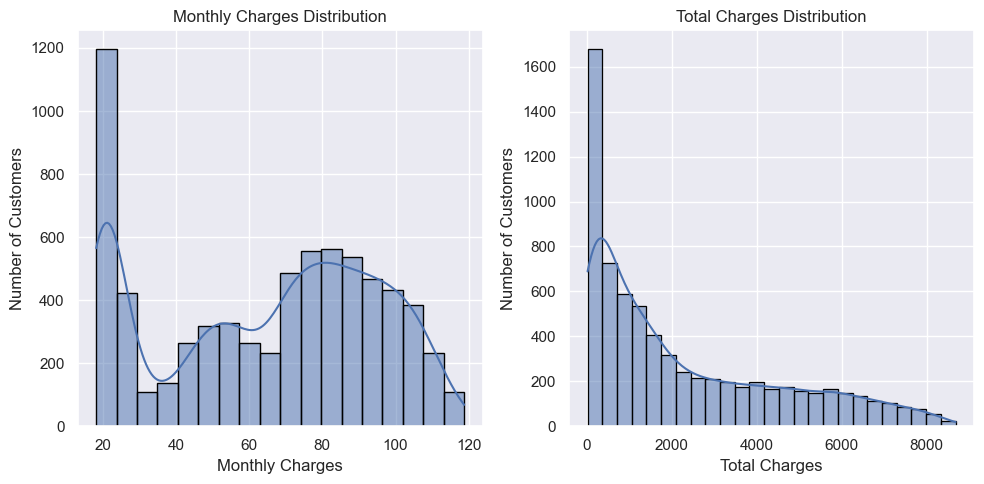

In [24]:
# Create side-by-side plots for billing feature distributions

fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10, 5)
)

# Plot the distribution of monthly charges

sns.histplot(
    data=df,
    x="MonthlyCharges",
    kde=True,
    palette="pastel",
    edgecolor="black",
    legend=False,
    ax=ax[0]
)

# Plot the distribution of total charges

sns.histplot(
    data=df,
    x="TotalCharges",
    kde=True,
    palette="pastel",
    edgecolor="black",
    legend=False,
    ax=ax[1]
)

# Customize the monthly charges plot

ax[0].set_title("Monthly Charges Distribution")
ax[0].set_xlabel("Monthly Charges")
ax[0].set_ylabel("Number of Customers")

# Customize the total charges plot

ax[1].set_title("Total Charges Distribution")
ax[1].set_xlabel("Total Charges")
ax[1].set_ylabel("Number of Customers")

# Adjust spacing between subplots

plt.tight_layout();

* the `MonthlyCharges` distribution is heterogeneous and contains several pronounced areas of value concentration. This may be related to differences in the set and type of subscribed services, although the cause cannot be determined from this visualization alone. The relationship between `MonthlyCharges`, `InternetService`, and other service-related features should be examined separately later;
* the `TotalCharges` distribution is strongly right-skewed: most customers are concentrated in the range of relatively low total charges, while high values occur much less frequently. Since `TotalCharges` accumulates over the entire service period, this distribution should also be examined in relation to `tenure` and `MonthlyCharges`.

## **4 Feature Relationships**

The univariate analysis suggested several potentially important connections between features. We now examine these relationships in more detail.

### **4.1 Partner and Dependents**

We first compare partner status with the presence of dependents.

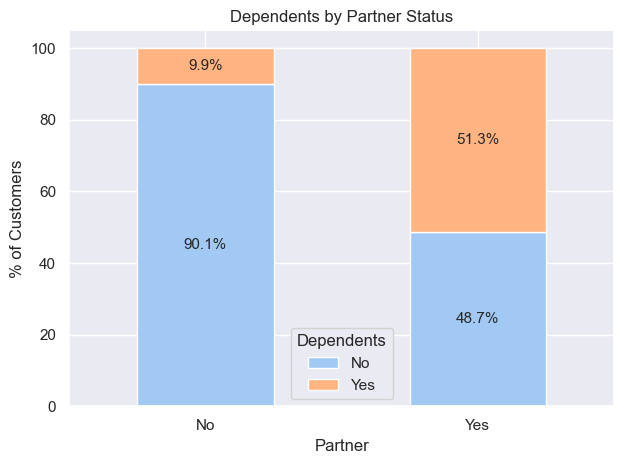

In [25]:
# Create a normalized contingency table for Partner and Dependents

cross = pd.crosstab(
    df["Partner"], 
    df["Dependents"],
    normalize="index"
) * 100

# Plot the percentage distribution of Dependents by Partner status

ax = cross.plot(
    kind="bar",
    stacked=True,
    color=sns.color_palette("pastel", 2)
)


# Add percentage labels inside each stacked bar

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{x:.1f}%" 
            for x in container.datavalues
        ],
        label_type="center",
        fontsize=11
    )

# Customize the plot title, axis labels, and legend

ax.set_title("Dependents by Partner Status")
ax.set_xlabel("Partner")
ax.set_ylabel("% of Customers")
ax.legend(title="Dependents")

# Keep x-axis labels horizontal and adjust spacing

plt.xticks(rotation=0)
plt.tight_layout();

* among customers without a partner, about 90% do not have dependents, while only about 10% have them;
* among customers with a partner, the distribution is almost even: 51.3% have dependents, while 48.7% do not.
  
Thus, having a partner is associated with a substantially higher proportion of customers with dependents.

### **4.2 Contract and Tenure**

To assess the link between contract type and customer tenure, we compare `tenure` across the three contract categories.

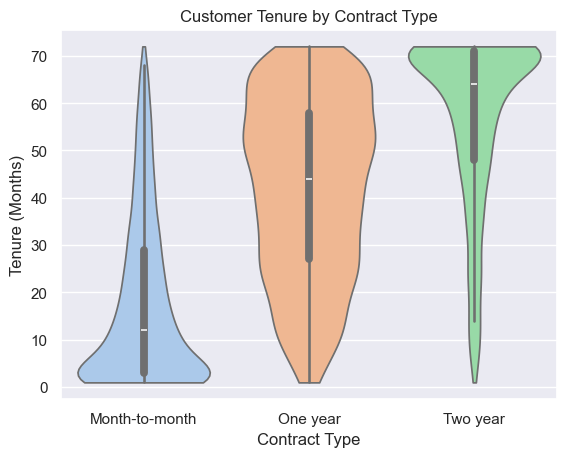

In [26]:
# Compare customer tenure across different contract types

sns.violinplot(
    data=df,
    x="Contract",
    y="tenure",
    hue="Contract",
    palette="pastel",
    cut=0
)

# Customize the plot title and axis labels

plt.title("Customer Tenure by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Tenure (Months)");

The visualization shows a clear association between contract type and customer tenure. Customers with month-to-month contracts tend to have lower `tenure` values, whereas customers with two-year contracts are much more likely to have longer service periods. One-year contracts occupy an intermediate position and show a broader distribution of `tenure`.

This pattern supports the earlier hypothesis that contract type and customer tenure are closely associated. The visualization, however, shows association rather than causation.

### **4.3 Monthly and Total Charges by Tenure**

We next explore how `MonthlyCharges` and tenure jointly relate to accumulated `TotalCharges`.

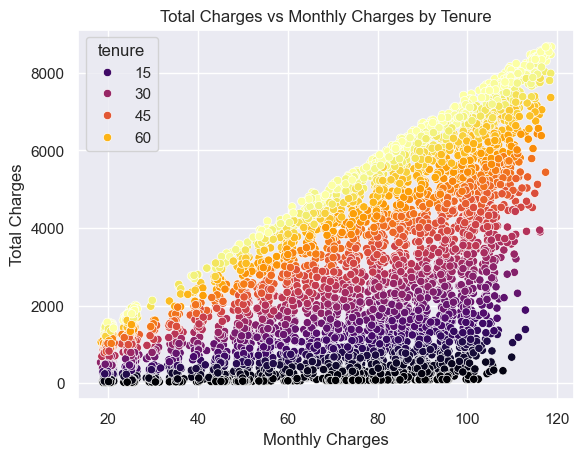

In [27]:
# Plot the relationship between monthly and total charges by customer tenure

sns.scatterplot(
    data=df,
    x="MonthlyCharges",
    y="TotalCharges",
    hue="tenure",
    palette="inferno"
)

# Customize the plot title and axis labels

plt.title("Total Charges vs Monthly Charges by Tenure")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges");

`MonthlyCharges` and `TotalCharges` are positively associated: higher monthly charges correspond to a wider range of accumulated total charges. `TotalCharges` also increases with `tenure`, as customers with longer service histories have had more time to accumulate charges.

### **4.4 Monthly Charges and InternetService**

The earlier analysis suggested that monthly charges may vary by internet service type. We test this by comparing `MonthlyCharges` across the `InternetService` categories.

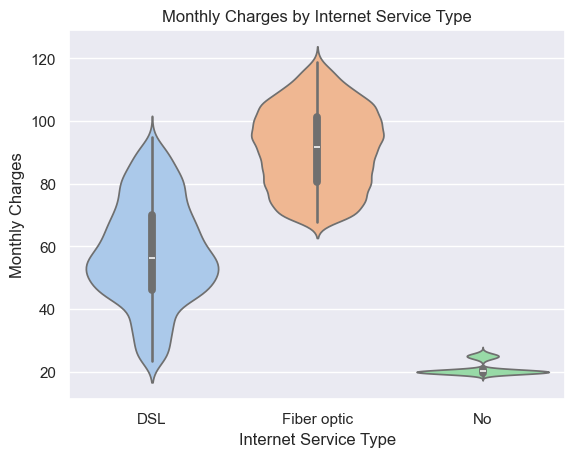

In [28]:
# Compare monthly charges across different internet service types

sns.violinplot(
    data=df,
    x="InternetService",
    y="MonthlyCharges",
    hue="InternetService",
    palette="pastel",
    legend=False,
);

# Customize the plot title and axis labels

plt.title("Monthly Charges by Internet Service Type")
plt.xlabel("Internet Service Type")
plt.ylabel("Monthly Charges");

The distribution of `MonthlyCharges` differs substantially across internet connection types:

* customers without internet service have the lowest monthly charges, concentrated at around 20;
* customers with `DSL` have a wider range of monthly charges, approximately from 20 to 90, with the main concentration around 50–60;
* customers with `Fiber optic` have higher monthly charges on average: most values are approximately in the range from 70 to 110.
  
Overall, monthly charges differ substantially by internet service type, with `Fiber optic` customers facing the highest charges.

### **4.5 Contract and Payment Method**

We then compare contract types across payment methods to determine whether the two features are associated.

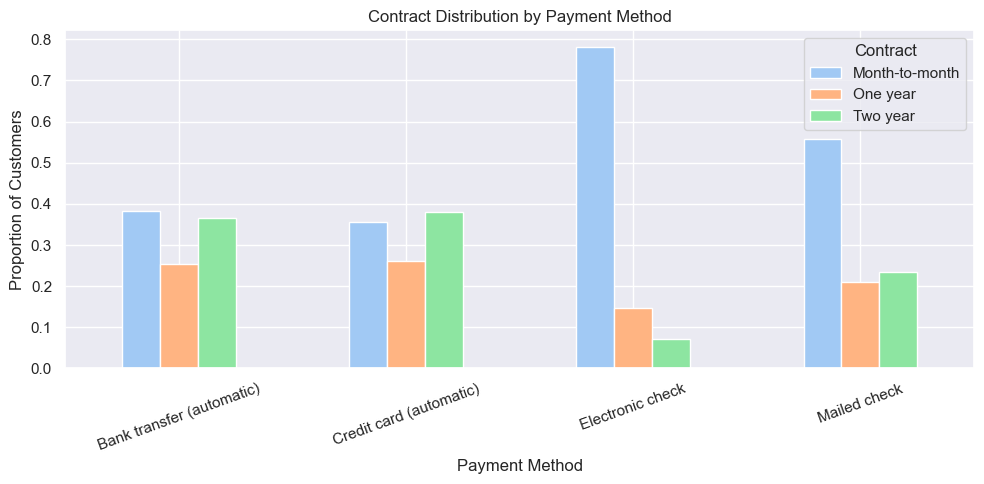

In [29]:
# Create a normalized contingency table for PaymentMethod and Contract

cross = pd.crosstab(
    df["PaymentMethod"],
    df["Contract"],
    normalize="index"
)

# Plot contract distribution within each payment method

ax = cross.plot(
    kind="bar",
    figsize=(10, 5),
    color=sns.color_palette("pastel", 3)
)

# Customize the plot title and axis labels

ax.set_title("Contract Distribution by Payment Method")
ax.set_xlabel("Payment Method")
ax.set_ylabel("Proportion of Customers")
ax.legend(title="Contract")

# Rotate x-axis labels for better readability

plt.xticks(rotation=20)
plt.tight_layout();

The pattern is particularly strong for `Electronic check`: about 78% of these customers use month-to-month contracts. Contract types are more evenly distributed across the other payment methods, suggesting a clear association between the two features.

### 4.6 **Tenure and Churn**

Comparing `tenure` for churned and retained customers reveals whether customer longevity is associated with churn.

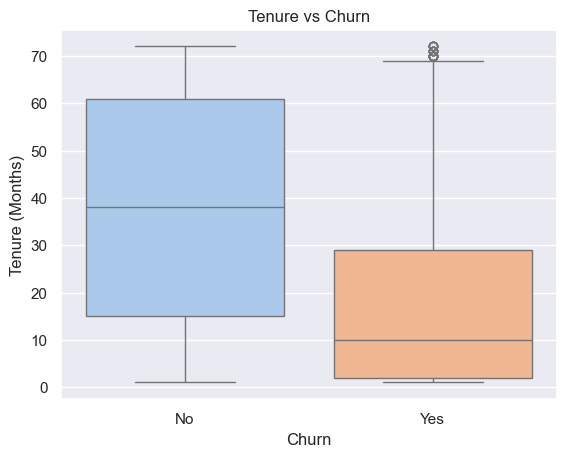

In [30]:
# Compare customer tenure between churn categories

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure",
    palette="pastel",
    legend=False
);

# Customize the plot title and axis labels

plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

# Replace binary churn values with readable labels

plt.xticks(ticks=[0, 1], labels=["No", "Yes"]);

* among customers who remained with the company, the median `tenure` is about 38 months, while the central 50% of observations are approximately between 15 and 60 months;
* among customers who churned, the median is considerably lower at about 10 months, with the central 50% of observations concentrated approximately between 2 and 29 months.
  
Churn is substantially more common among customers with shorter tenure. This pattern indicates an association, not evidence that shorter tenure itself causes churn.

### 4.7 **Contract and Churn**

Churn rates are then compared across month-to-month, one-year, and two-year contracts.

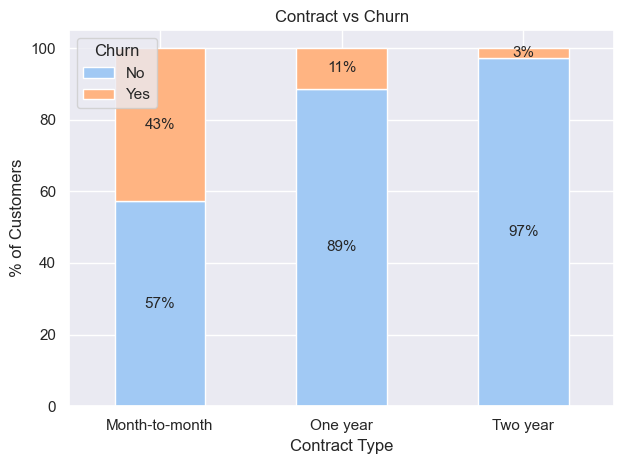

In [31]:
# Create a normalized contingency table for Contract and Churn

cross = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

# Plot churn distribution within each contract type

ax = cross.plot(
    kind="bar",
    stacked=True,
    color=sns.color_palette("pastel", 2)
)

# Add percentage labels inside each stacked bar

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{x:.0f}%"
            for x in container.datavalues
        ],
        label_type="center",
        fontsize=11
    )

# Customize the plot title, axis labels, and legend

ax.set_title("Contract vs Churn")
ax.set_xlabel("Contract Type")
ax.set_ylabel("% of Customers")
ax.legend(title="Churn",labels=["No", "Yes"])

# Keep x-axis labels horizontal and adjust spacing

plt.xticks(rotation=0)
plt.tight_layout();

Churn falls sharply as contract length increases: from about 43% for month-to-month customers to 11% for one-year contracts and just 3% for two-year contracts. Contract type is therefore one of the clearest churn-related features in the dataset.

### **4.8 Internet Service and Churn**

Churn rates also vary across internet service types, so we compare `DSL`, `Fiber optic`, and customers without internet service.

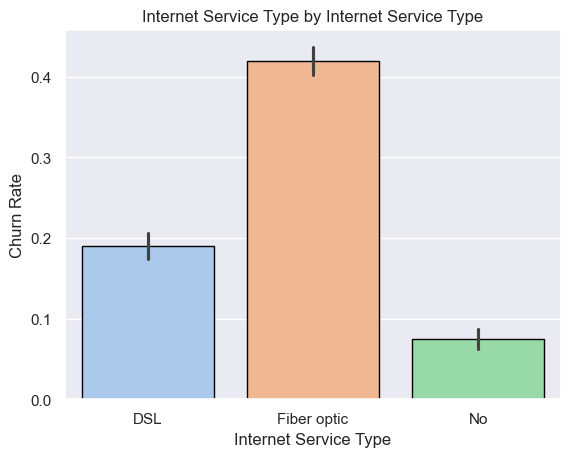

In [32]:
# Compare churn rates across internet service types

sns.barplot(
    data=df,
    x="InternetService",
    y="Churn",
    hue="InternetService",
    palette="pastel",
    edgecolor="black",
    legend=False
)

# Customize the plot title and axis labels

plt.title("Internet Service Type by Internet Service Type")
plt.xlabel("Internet Service Type")
plt.ylabel("Churn Rate");

The highest churn rate is observed among customers with `Fiber optic`. When interpreting this relationship, it should be taken into account that this group is also characterized by higher `MonthlyCharges`.

### **4.9 Monthly Charges and Churn**

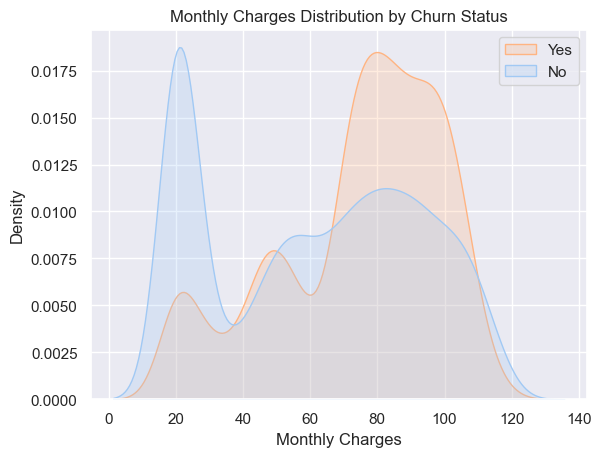

In [33]:
# Plot MonthlyCharges distributions by churn status

sns.kdeplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    palette="pastel",
    common_norm=False,
    fill=True,
)

# Customize the plot title, axis labels, and legend

plt.title("Monthly Charges Distribution by Churn Status")
plt.xlabel("Monthly Charges")
plt.ylabel("Density")
plt.legend(["Yes", "No"]);

* among customers who churned, the distribution of `MonthlyCharges` is shifted toward higher values: the main concentration of observations is approximately in the range from 70 to 105;
* among customers who remained, there is a pronounced peak in the lower monthly charge range, approximately around 20–30, while a broad group of customers with higher values is also present.
  
Overall, customers who churned tend to have higher `MonthlyCharges`. This is consistent with the earlier `InternetService` analysis: `Fiber optic` customers have both the highest monthly charges and the highest churn rate. The effects of `MonthlyCharges` and internet service type should therefore be interpreted together.

### **4.10 Total Charges and Churn**

We also compare `TotalCharges` between churned and retained customers.

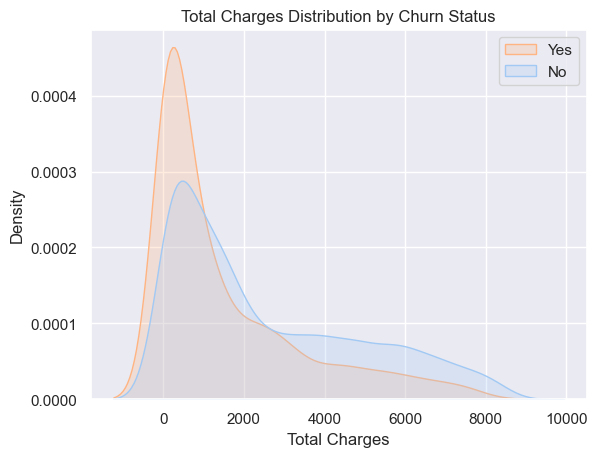

In [34]:
# Plot TotalCharges distributions by churn status

sns.kdeplot(
    data=df,
    x="TotalCharges",
    hue="Churn",
    palette="pastel",
    common_norm=False,
    fill=True,
);

# Customize the plot title, axis labels, and legend

plt.title("Total Charges Distribution by Churn Status")
plt.xlabel("Total Charges")
plt.ylabel("Density")
plt.legend(["Yes", "No"]);

Customers who churned predominantly have low `TotalCharges` values. However, this effect is closely related to `tenure`: customers with shorter service periods also have less time to accumulate total charges.

### **4.11 Senior Citizens and Churn**

Finally, we compare churn rates between senior and non-senior customers. Senior customers represent only about 16% of the sample, which should be kept in mind when interpreting the difference.

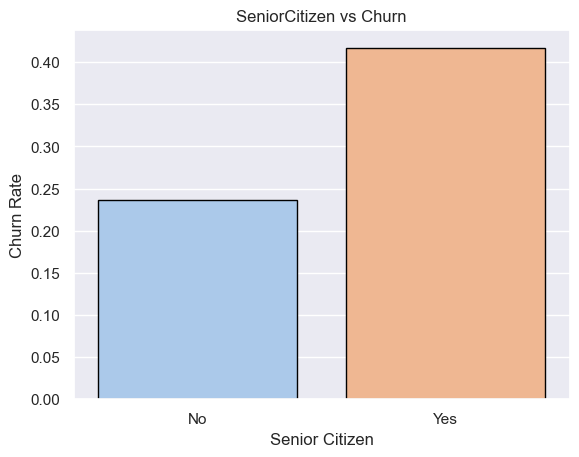

In [35]:
# Compare churn rates between senior and non-senior customers

sns.barplot(
    data=df,
    x="SeniorCitizen",
    y="Churn",
    hue="SeniorCitizen",
    palette="pastel",
    edgecolor="black",
    legend=False,
    ci=False
);

# Customize the plot title and axis labels

plt.title("SeniorCitizen vs Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate")
plt.xticks(ticks=[0, 1], labels=["No", "Yes"]);

Despite their lower representation in the sample, senior customers have a noticeably higher churn rate: about 42% compared with approximately 24% among non-senior customers. This indicates a pronounced relationship between `SeniorCitizen` and `Churn`, although the plot itself does not explain the reasons for this difference.

### **4.12 Correlation Matrix**

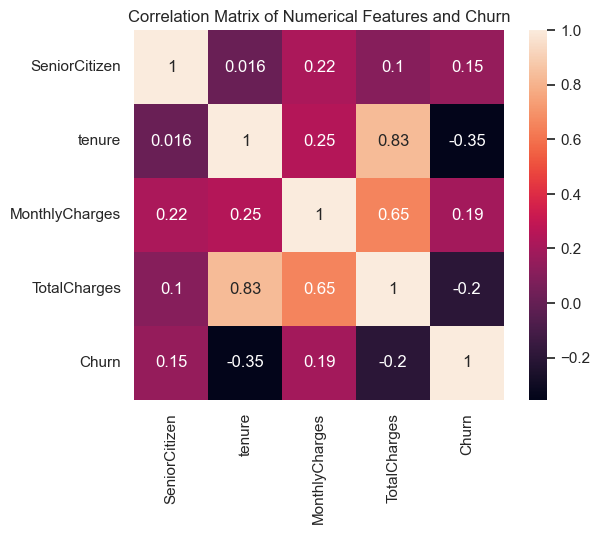

In [36]:
# Calculate the correlation matrix for numerical features

corr_matrix = df.corr(numeric_only=True)


# Visualize the correlation matrix

sns.heatmap(
    corr_matrix,
    square=True,
    annot=True
)

# Customize the plot title

plt.title("Correlation Matrix of Numerical Features and Churn");

### **4.13 EDA Conclusions**

EDA shows that churn is most strongly associated with `tenure`, contract type, monthly charges, and internet service. Customers with shorter service periods, month-to-month contracts, and higher `MonthlyCharges` churn more frequently.

Several of these features are also related to one another: `TotalCharges` largely depends on `tenure`, while higher `MonthlyCharges` are more common among customers with `Fiber optic`. Therefore, when building models, it is important to consider not only individual features but also the relationships between them.

`SeniorCitizen` is also associated with churn, although the pattern is weaker than for the main factors identified above.

## **5 Data Preprocessing and Model Training**

### **5.1 Data Preprocessing**

We now proceed to data preparation and pipeline construction for training machine learning models. Three classification algorithms will be considered: KNN, logistic regression, and SVM.

At the Feature Engineering stage, we will not create any additional features. Preliminary experiments with removing correlated features and engineering new features, such as the number of subscribed services, did not improve model performance. The original features already capture customer characteristics and service usage in sufficient detail.

From the original features, we will remove only `PhoneService`. As noted during the EDA, it partially duplicates information from `MultipleLines`, since the `No phone service` category already explicitly indicates the absence of phone service.

Categorical features will be converted into dummy variables so that the models can work with them in numerical format.

In [37]:
# Remove the redundant PhoneService feature

df = df.drop("PhoneService", axis=1)

In [38]:
# Encode categorical features using dummy variables

df = pd.get_dummies(df, drop_first=True)

### **5.2 Model Training**

In [39]:
# Import pipeline tools and classification models

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Import feature scaling method

from sklearn.preprocessing import StandardScaler

# Import data splitting, cross-validation, and hyperparameter tuning tools

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

# Import model evaluation metrics and visualization tools

from sklearn.metrics import (
    classification_report,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
)

# Import permutation feature importance for model interpretation

from sklearn.inspection import permutation_importance

In [40]:
# Separate features from the target variable

X = df.drop("Churn", axis=1)
y = df["Churn"]

In [41]:
# Split the data into training and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Since the target variable is imbalanced, we use `StratifiedKFold` to preserve approximately the same class proportions in each fold and obtain a more stable estimate of model performance.

In [42]:
# Define stratified cross-validation to preserve class proportions

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#### **5.2.1 K-Nearest Neighbors**

In [43]:
# Create a pipeline with feature scaling and KNN classifier

knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

In [44]:
# Define the hyperparameter grid for KNN

param_grid = {
    "knn__n_neighbors": np.arange(3, 31, 2),
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]
}

In [45]:
# Configure grid search with stratified cross-validation

knn_grid = GridSearchCV(
    knn_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

In [46]:
# Fit the KNN model and search for the best hyperparameters

knn_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'knn__n_neighbors': array([ 3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]),
                         'knn__p': [1, 2],
                         'knn__weights': ['uniform', 'distance']},
             scoring='roc_auc')

In [47]:
# Display the best hyperparameters found by grid search

knn_grid.best_params_

{'knn__n_neighbors': np.int64(29), 'knn__p': 1, 'knn__weights': 'uniform'}

In [48]:
# Generate predictions on the test set

y_knn_pred = knn_grid.predict(X_test)

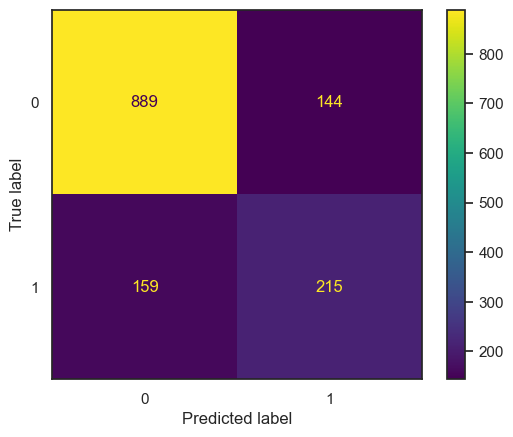

In [49]:
# Display the confusion matrix for the best KNN model

with sns.axes_style("white"):
    ConfusionMatrixDisplay.from_estimator(
        knn_grid,
        X_test,
        y_test
    );

In [50]:
# Display the classification report for the KNN model

print(classification_report(y_test, y_knn_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1033
           1       0.60      0.57      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



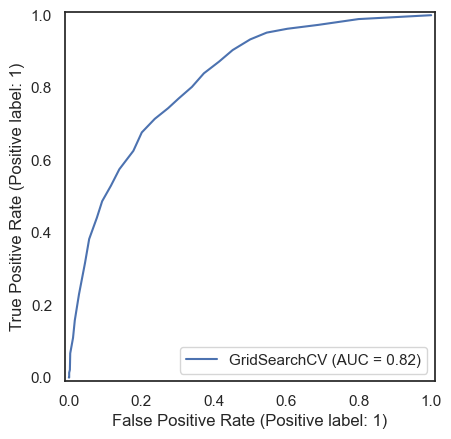

In [51]:
# Plot the ROC curve for the best KNN model

with sns.axes_style("white"):
    RocCurveDisplay.from_estimator(
        knn_grid,
        X_test,
        y_test
    );

In [52]:
# Calculate permutation feature importance for the best KNN model

perm_importance = permutation_importance(
    knn_grid,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

In [53]:
# Store feature importance scores and their variability

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean,
    "Std": perm_importance.importances_std
}).sort_values("Importance", ascending=False)

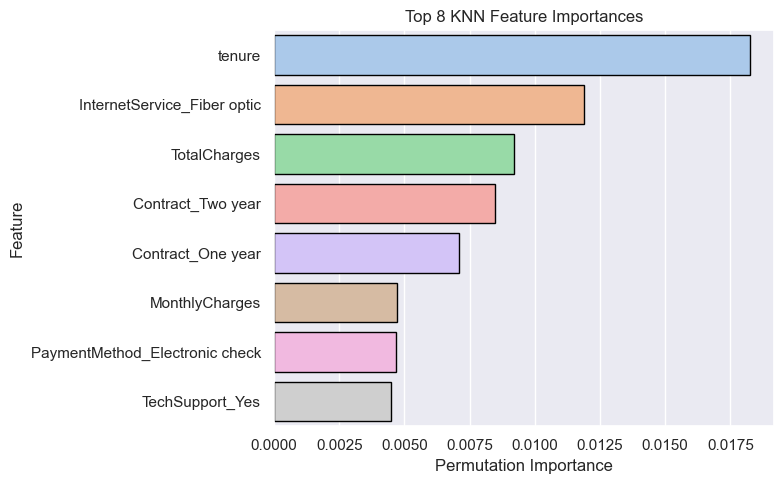

In [54]:
# Select the 8 most important features for knn

top_features = feature_importance.head(8)

# Plot the most important features

plt.figure(figsize=(8, 5))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="pastel",
    edgecolor="black",
    legend=False
)

# Customize the plot title and axis labels

plt.title("Top 8 KNN Feature Importances")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")

plt.tight_layout();

**Observations**:
* the best KNN configuration uses 29 neighbors, Manhattan distance (p=1), and uniform weights;
* the model achieves an accuracy of 0.78. For the Churn = 1 class, precision is 0.60, recall is 0.57, and F1-score is 0.59. This indicates that KNN identifies only slightly more than half of the customers who actually churn;
* performance is noticeably stronger for retained customers than for churned customers, reflecting the difficulty of identifying the minority class;
* Permutation Importance primarily highlights tenure, InternetService_Fiber optic, TotalCharges, contract type, and MonthlyCharges, which is broadly consistent with the EDA findings.

#### **5.2.2 Logistic Regression**

In [55]:
# Create a pipeline with feature scaling and logistic regression

log_regression_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("log_regression", LogisticRegression(max_iter=10000))
])

In [56]:
# Define compatible hyperparameter combinations for logistic regression

param_grid = [
    {
        "log_regression__solver": ["liblinear"],
        "log_regression__penalty": ["l1", "l2"],
        "log_regression__C": np.logspace(-4, 4, 9),
    },
    {
        "log_regression__solver": ["lbfgs"],
        "log_regression__penalty": ["l2"],
        "log_regression__C": np.logspace(-4, 4, 9),
        
    },
    {
        "log_regression__solver": ["saga"],
        "log_regression__penalty": ["elasticnet"],
        "log_regression__l1_ratio": [0.25, 0.5, 0.75],
        "log_regression__C": np.logspace(-4, 4, 9),
        
    },
    
]

In [57]:
# Configure grid search for logistic regression

log_regression_grid = GridSearchCV(
    log_regression_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

In [58]:
# Fit the logistic regression model and search for the best hyperparameters

log_regression_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('log_regression',
                                        LogisticRegression(max_iter=10000))]),
             n_jobs=-1,
             param_grid=[{'log_regression__C': array([1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03,
       1.e+04]),
                          'log_regression__penalty': ['l1', 'l2'],
                          'log_regressio...
                         {'log_regression__C': array([1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03,
       1.e+04]),
                          'log_regression__penalty': ['l2'],
                          'log_regression__solver': ['lbfgs']},
                         {'log_regression__C': array([1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03,
       1.e+04]),
                          'log_regression__l1_ratio': [0.25, 0.5, 0.75],
                          'log_regression__penalty': ['elasticnet'],
                          'log_regression__solver': ['saga']}],
             scoring='roc_auc')

In [59]:
# Display the best hyperparameters found by grid search

log_regression_grid.best_params_

{'log_regression__C': np.float64(10.0),
 'log_regression__penalty': 'l2',
 'log_regression__solver': 'liblinear'}

In [60]:
# Generate predictions on the test set

y_log_regression_pred = log_regression_grid.predict(X_test)

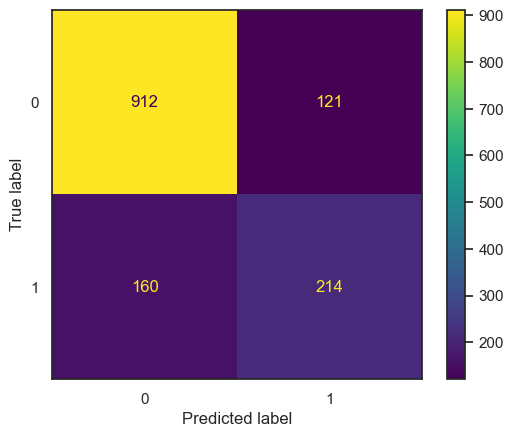

In [61]:
# Display the confusion matrix for the best logistic regression model

with sns.axes_style("white"):
    ConfusionMatrixDisplay.from_estimator(
        log_regression_grid,
        X_test,
        y_test
    );

In [62]:
# Display the classification report for logistic regression

print(classification_report(y_test, y_log_regression_pred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1033
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.73      0.74      1407
weighted avg       0.79      0.80      0.80      1407



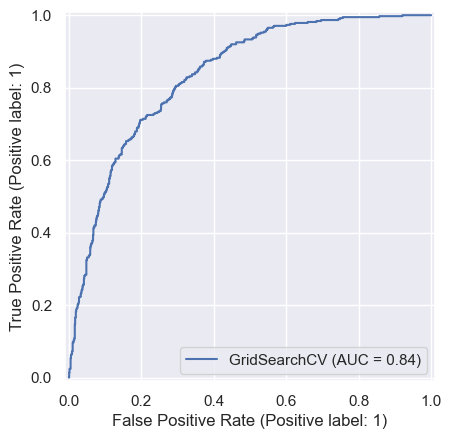

In [63]:
# Plot the ROC curve for the best logistic regression model

RocCurveDisplay.from_estimator(
    log_regression_grid,
    X_test,
    y_test
);

In [64]:
# Calculate permutation feature importance for the best logistic regression model

perm_importance_log = permutation_importance(
    log_regression_grid,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

In [65]:
# Store feature importance scores and their variability

feature_importance_log = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance_log.importances_mean,
    "Std": perm_importance_log.importances_std
}).sort_values("Importance", ascending=False)

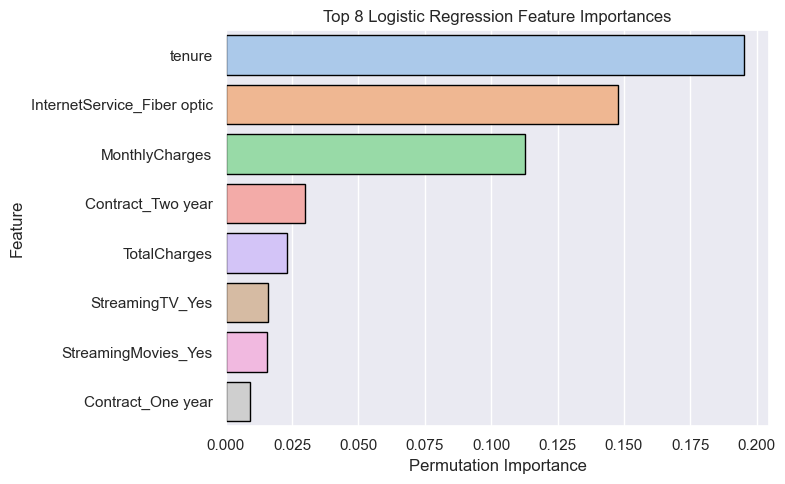

In [66]:
# Select the 8 most important features for logistic regression

top_features_log = feature_importance_log.head(8)

# Plot the most important features for logistic regression

plt.figure(figsize=(8, 5))

sns.barplot(
    data=top_features_log,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="pastel",
    edgecolor="black",
    legend=False
)

# Customize the plot title and axis labels

plt.title("Top 8 Logistic Regression Feature Importances")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")

# Adjust plot spacing

plt.tight_layout();

**Observations**:
* the best logistic regression model uses L2 regularization, C = 10, and the liblinear solver;
* the model achieves an accuracy of 0.80. For the Churn = 1 class, precision is 0.64, recall is 0.57, and F1-score is 0.60;
* compared with KNN, logistic regression provides higher overall accuracy and better precision for the churn class, while recall remains the same at 0.57;
* the model therefore produces fewer false positive churn predictions than KNN, although it still fails to identify a considerable share of customers who actually churn;
* Permutation Importance again highlights tenure, TotalCharges, contract type, and InternetService_Fiber optic, supporting the patterns identified during the EDA.

#### **5.2.3 Support Vector Machine**

In [67]:
# Create a pipeline with feature scaling and SVM classifier

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(random_state=42))
])

In [68]:
# Define compatible hyperparameter combinations for SVM

param_grid = [
    {
        "svm__kernel": ["linear"],
        "svm__C": [0.001, 0.01, 0.1, 1, 10],
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.001, 0.01, 0.1, 1, 10],
        "svm__gamma": ["scale", 0.01, 0.1],
    }
]

In [69]:
# Configure grid search for SVM

svm_grid = GridSearchCV(
    svm_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1   
)

In [70]:
# Fit the SVM model and search for the best hyperparameters

svm_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'svm__C': [0.001, 0.01, 0.1, 1, 10],
                          'svm__kernel': ['linear']},
                         {'svm__C': [0.001, 0.01, 0.1, 1, 10],
                          'svm__gamma': ['scale', 0.01, 0.1],
                          'svm__kernel': ['rbf']}],
             scoring='roc_auc')

In [71]:
# Display the best hyperparameters found by grid search

svm_grid.best_params_

{'svm__C': 0.01, 'svm__kernel': 'linear'}

In [72]:
# Generate predictions on the test set

y_svm_pred = svm_grid.predict(X_test)

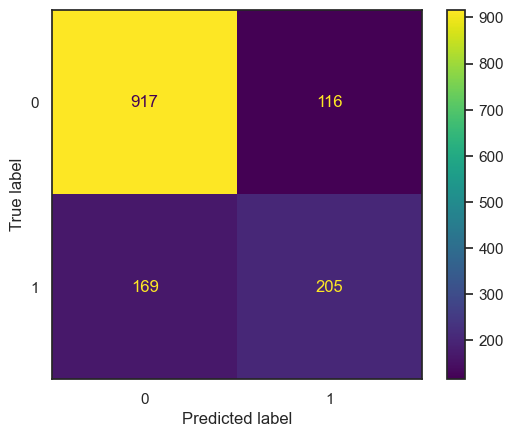

In [73]:
# Display the confusion matrix for the best SVM model

with sns.axes_style("white"):
    ConfusionMatrixDisplay.from_estimator(
        svm_grid,
        X_test,
        y_test
    );

In [74]:
# Display the classification report for the SVM model

print(classification_report(y_test, y_svm_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



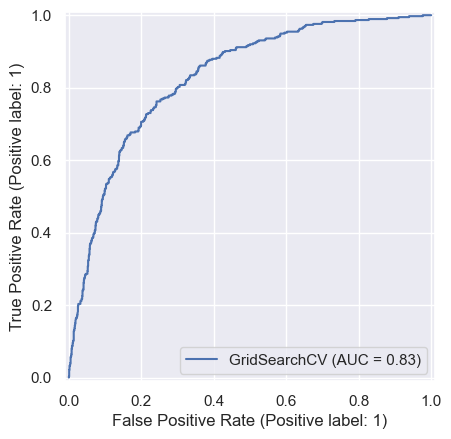

In [75]:
# Plot the ROC curve for the best SVM model

RocCurveDisplay.from_estimator(
    svm_grid,
    X_test,
    y_test
);

In [76]:
# Calculate permutation feature importance for the best SVM model

perm_importance_svm = permutation_importance(
    svm_grid,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

In [77]:
# Store feature importance scores and their variability

feature_importance_svm = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance_svm.importances_mean,
    "Std": perm_importance_svm.importances_std
}).sort_values("Importance", ascending=False)

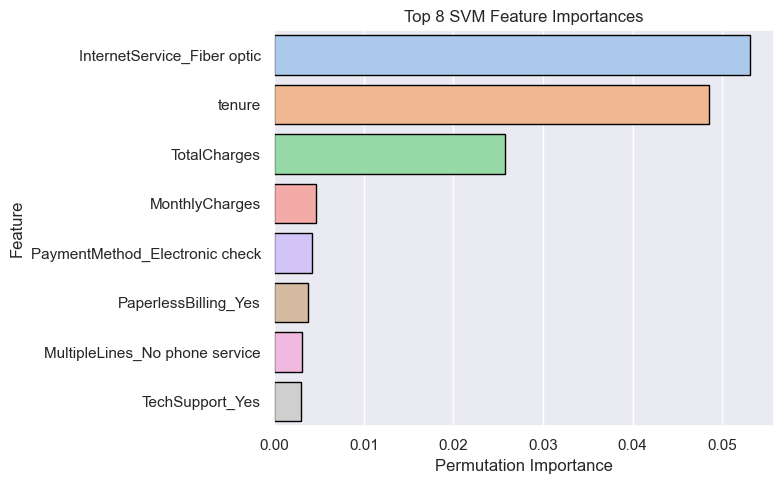

In [78]:
# Select the 8 most important features for SVM

top_features_svm = feature_importance_svm.head(8)

# Plot the most important features for the SVM model

plt.figure(figsize=(8, 5))

sns.barplot(
    data=top_features_svm,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="pastel",
    edgecolor="black",
    legend=False
)

# Customize the plot title and axis labels

plt.title("Top 8 SVM Feature Importances")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")

# Adjust plot spacing

plt.tight_layout()

**Observations**:
* the best SVM configuration uses a linear kernel and C = 0.01, suggesting that a more complex nonlinear decision boundary does not provide an advantage for this dataset;
* the model achieves an accuracy of 0.80. For the Churn = 1 class, precision is 0.64, recall is 0.55, and F1-score is 0.59;
* its predictive performance is very similar to logistic regression: both models achieve the same accuracy and precision for the churn class, while logistic regression has slightly higher recall and F1-score;
* the most important features include InternetService_Fiber optic, tenure, MonthlyCharges, and several service-related variables, which is generally consistent with both the EDA and the other models;
* overall, SVM performs slightly better than KNN in terms of accuracy and precision, but does not provide a clear advantage over logistic regression.

---

Thank you for reading.

Best regards, Mendel.